In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [21]:
df = pd.read_excel("AlloyTower.xlsx")
df.to_csv("alloy_dataset.csv", index=False)
df.head()

,property_id,id,full_address,street_address,unit,city,state,zip_code,county,latitude,longitude,property_type,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,building_age,last_sale_price,last_sale_date,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax,owner_name,owner_occupied,assessor_id,building_age_grp
0,P-100003,10003,"8885 Park Way, Apt 21C, Kansas City, MO 59615",8885 Park Way,Apt 21C,Kansas City,MO,59615,Jackson,23.088205,-131.493490,Townhouse,7,3.5,5329,8479,2010,14,174253.02,13/11/2018,2709,32.70,151316.00,2023,2999.49,Joseph Miller,True,MO-JA-69429,New
1,P-100005,10005,"625 Ridgewood Rd, Apt 14E, Tucson, AZ 62581",625 Ridgewood Rd,Apt 14E,Tucson,AZ,62581,Pima,28.095133,-138.644493,Townhouse,6,3.5,2341,13079,1983,41,428592.88,27/01/2019,2634,183.08,401872.50,2023,3888.34,Deborah Scott,True,AZ-PI-86622,Mid-age
2,P-100008,10008,"2746 Main St, Apt 22D, Cleveland, OH 88504",2746 Main St,Apt 22D,Cleveland,OH,88504,Cuyahoga,29.590136,-155.305523,Townhouse,7,3.0,2561,3510,1950,74,804847.49,26/05/2025,323,314.27,664559.38,2023,11824.03,Ronald Wright,False,OH-CU-26828,Old
3,P-100009,10009,"2805 Adams St, Apt 19E, Indianapolis, IN 79163",2805 Adams St,Apt 19E,Indianapolis,IN,79163,Marion,44.119476,-120.186999,Condo,5,2.5,6440,11547,1971,53,896216.50,30/12/2018,2662,139.16,817372.88,2024,10967.37,Sarah Anderson,True,IN-MA-12757,Old
4,P-100010,10010,"9741 Madison Ave, Apt 26D, Tucson, AZ 10942",9741 Madison Ave,Apt 26D,Tucson,AZ,10942,Pima,22.881317,-102.094043,Condo,1,1.0,3306,4466,1985,39,305643.61,12/10/2018,2741,92.45,289024.04,2024,2771.09,Kenneth Torres,True,AZ-PI-71993,Mid-age


In [23]:
df['property_type'].value_counts()

property_type
Condo        462
Townhouse    322
Name: count, dtype: int64

In [13]:
df['last_sale_date'] = pd.to_datetime(df['last_sale_date'], errors='coerce')

C:\Users\Edith Philip\AppData\Local\Temp\ipykernel_29164\3957892335.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last_sale_date'] = pd.to_datetime(df['last_sale_date'], errors='coerce')


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 784 entries, 0 to 783
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       784 non-null    str    
 1   id                784 non-null    int64  
 2   full_address      784 non-null    str    
 3   street_address    784 non-null    str    
 4   unit              784 non-null    str    
 5   city              784 non-null    str    
 6   state             784 non-null    str    
 7   zip_code          784 non-null    int64  
 8   county            784 non-null    str    
 9   latitude          784 non-null    float64
 10  longitude         784 non-null    float64
 11  property_type     784 non-null    str    
 12  bedrooms          784 non-null    int64  
 13  bathrooms         784 non-null    float64
 14  sqft              784 non-null    int64  
 15  lot_size_sqft     784 non-null    int64  
 16  year_built        784 non-null    int64  
 17  building

In [25]:
df.describe()

,id,zip_code,latitude,longitude,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,building_age,last_sale_price,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax
count,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,784.000000,7.840000e+02,784.000000,784.000000,7.840000e+02,784.000000,784.000000
mean,11020.674745,54015.165816,34.141496,-113.502343,4.026786,2.975765,3774.042092,9794.022959,1972.466837,51.533163,7.699288e+05,1835.108418,249.815077,7.292224e+05,2022.982143,11152.386008
std,642.465068,25916.330048,7.620716,25.401937,2.031815,1.320842,1672.899054,3780.596289,30.256104,30.256104,6.165187e+05,1070.278305,204.699264,5.993097e+05,0.797305,10355.320910
min,10003.000000,10205.000000,21.014436,-156.964683,1.000000,1.000000,610.000000,1224.000000,1920.000000,1.000000,1.234157e+05,3.000000,20.470000,1.034726e+05,2022.000000,1057.280000
25%,10462.750000,30995.250000,27.480506,-135.872126,2.000000,2.000000,2370.000000,6897.000000,1946.000000,25.000000,3.978931e+05,914.750000,108.747500,3.810676e+05,2022.000000,5014.287500
50%,10962.000000,54515.500000,33.728780,-114.091289,4.000000,3.000000,3803.500000,9670.500000,1974.000000,50.000000,6.111738e+05,1820.000000,171.610000,5.857394e+05,2023.000000,8082.855000
75%,11544.500000,76938.500000,40.850814,-90.672781,6.000000,4.000000,5314.500000,12561.250000,1999.000000,78.000000,8.409561e+05,2750.250000,338.702500,7.831497e+05,2024.000000,13103.325000
max,12226.000000,99839.000000,47.440233,-70.242064,7.000000,5.000000,6498.000000,18413.000000,2023.000000,104.000000,3.399397e+06,3643.000000,975.470000,3.469261e+06,2024.000000,69097.810000


In [26]:
df.isnull().sum()

property_id         0
id                  0
full_address        0
street_address      0
unit                0
city                0
state               0
zip_code            0
county              0
latitude            0
longitude           0
property_type       0
bedrooms            0
bathrooms           0
sqft                0
lot_size_sqft       0
year_built          0
building_age        0
last_sale_price     0
last_sale_date      0
days_since_sale     0
price_per_sqft      0
assessed_value      0
tax_year            0
annual_tax          0
owner_name          0
owner_occupied      0
assessor_id         0
building_age_grp    0
dtype: int64

In [27]:
print(df.shape)
df.columns

(784, 29)


Index(['property_id', 'id', 'full_address', 'street_address', 'unit', 'city',
       'state', 'zip_code', 'county', 'latitude', 'longitude', 'property_type',
       'bedrooms', 'bathrooms', 'sqft', 'lot_size_sqft', 'year_built',
       'building_age', 'last_sale_price', 'last_sale_date', 'days_since_sale',
       'price_per_sqft', 'assessed_value', 'tax_year', 'annual_tax',
       'owner_name', 'owner_occupied', 'assessor_id', 'building_age_grp'],
      dtype='str')

In [28]:
df.groupby("property_type")["last_sale_price"].mean()

property_type
Condo        775658.661494
Townhouse    761707.769752
Name: last_sale_price, dtype: float64

In [29]:
# This gives:

# Which property type is most expensive
# Investment insights
df.groupby("property_type")["price_per_sqft"].mean()

property_type
Condo        253.528203
Townhouse    244.487547
Name: price_per_sqft, dtype: float64

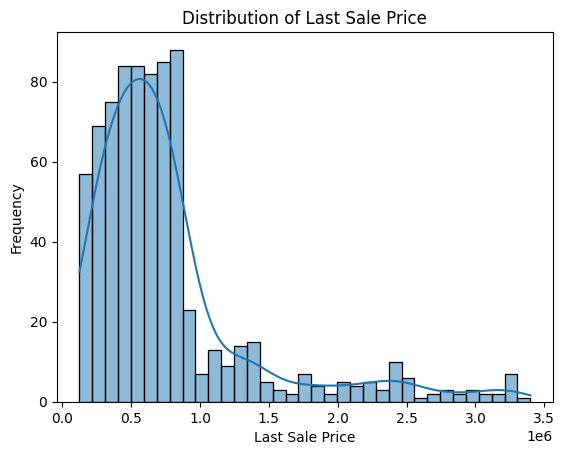

In [ ]:
# Histogram - Distribution of Sale Price

sns.histplot(df["last_sale_price"], kde=True)
plt.title("Distribution of Last Sale Price")
plt.xlabel("Last Sale Price")
plt.ylabel("Frequency")
plt.show()

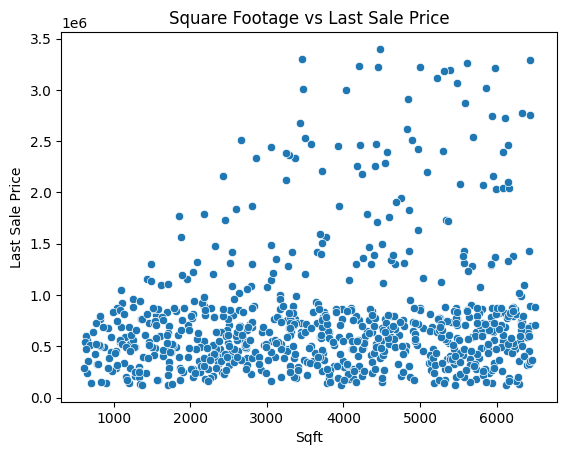

In [ ]:
# # Scatter plot
# Relationship: Sqft vs Price

sns.scatterplot(x="sqft", y="last_sale_price", data=df)
plt.title("Square Footage vs Last Sale Price")
plt.xlabel("Sqft")
plt.ylabel("Last Sale Price")
plt.show()

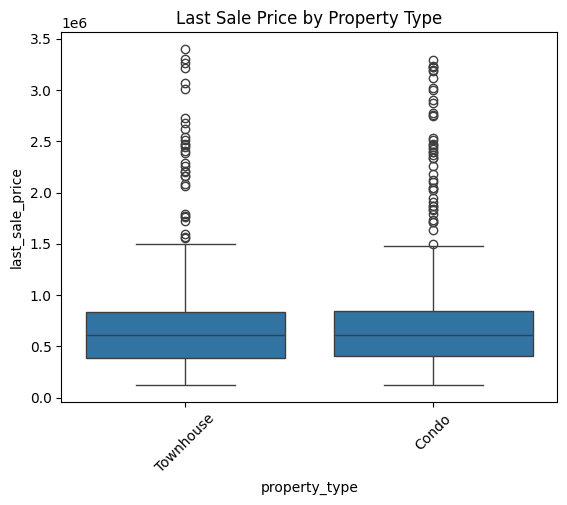

In [32]:
# Price by Property Type
sns.boxplot(x="property_type", y="last_sale_price", data=df)
plt.title("Last Sale Price by Property Type")
plt.xticks(rotation=45)
plt.show()

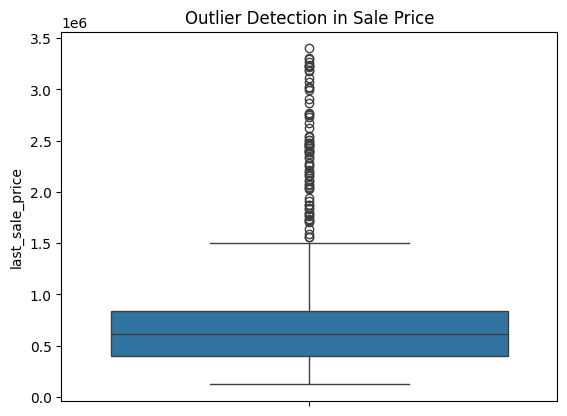

In [48]:
sns.boxplot(y=df["last_sale_price"])
plt.title("Outlier Detection in Sale Price")
plt.show()

In [49]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('id')  # Exclude 'id' if it's numeric but not relevant for correlation

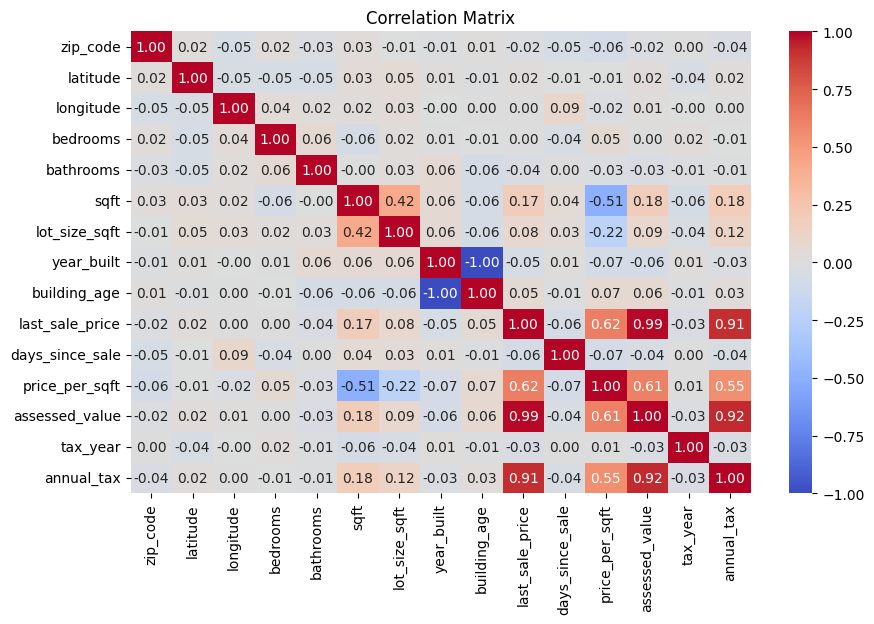

In [50]:
# Correlation Heatmap

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [38]:
df[numeric_cols].corr()

,zip_code,latitude,longitude,bedrooms,bathrooms,sqft,lot_size_sqft,year_built,building_age,last_sale_price,days_since_sale,price_per_sqft,assessed_value,tax_year,annual_tax
zip_code,1.000000,0.021310,-0.052031,0.023181,-0.030912,0.030076,-0.005319,-0.008659,0.008659,-0.021192,-0.053142,-0.063742,-0.019474,0.000276,-0.038617
latitude,0.021310,1.000000,-0.045965,-0.050037,-0.049960,0.032784,0.046075,0.007820,-0.007820,0.021643,-0.006387,-0.005732,0.023453,-0.040512,0.017087
longitude,-0.052031,-0.045965,1.000000,0.036821,0.019795,0.020348,0.033104,-0.001817,0.001817,0.000473,0.091948,-0.024816,0.010169,-0.001980,0.003285
bedrooms,0.023181,-0.050037,0.036821,1.000000,0.061632,-0.062316,0.015678,0.005738,-0.005738,0.004258,-0.041754,0.049424,0.001022,0.024735,-0.007442
bathrooms,-0.030912,-0.049960,0.019795,0.061632,1.000000,-0.003356,0.031220,0.062121,-0.062121,-0.036705,0.001386,-0.029570,-0.031889,-0.009507,-0.013681
sqft,0.030076,0.032784,0.020348,-0.062316,-0.003356,1.000000,0.416000,0.057230,-0.057230,0.173643,0.040330,-0.505503,0.175382,-0.057077,0.181368
lot_size_sqft,-0.005319,0.046075,0.033104,0.015678,0.031220,0.416000,1.000000,0.055088,-0.055088,0.080534,0.033456,-0.221411,0.085798,-0.039098,0.120418
year_built,-0.008659,0.007820,-0.001817,0.005738,0.062121,0.057230,0.055088,1.000000,-1.000000,-0.052732,0.009708,-0.065506,-0.062638,0.012946,-0.030679
building_age,0.008659,-0.007820,0.001817,-0.005738,-0.062121,-0.057230,-0.055088,-1.000000,1.000000,0.052732,-0.009708,0.065506,0.062638,-0.012946,0.030679
last_sale_price,-0.021192,0.021643,0.000473,0.004258,-0.036705,0.173643,0.080534,-0.052732,0.052732,1.000000,-0.058839,0.623955,0.989653,-0.032228,0.914223


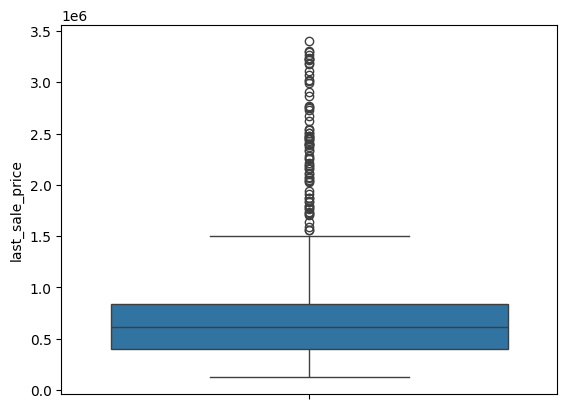

In [39]:
sns.boxplot(y=df["last_sale_price"])
plt.show()

In [ ]:
# df["property_type"].value_counts().plot(kind='bar')
# plt.title("Distribution of Property Types")
# plt.xlabel("Property Type")
# plt.ylabel("Count")
# plt.show()